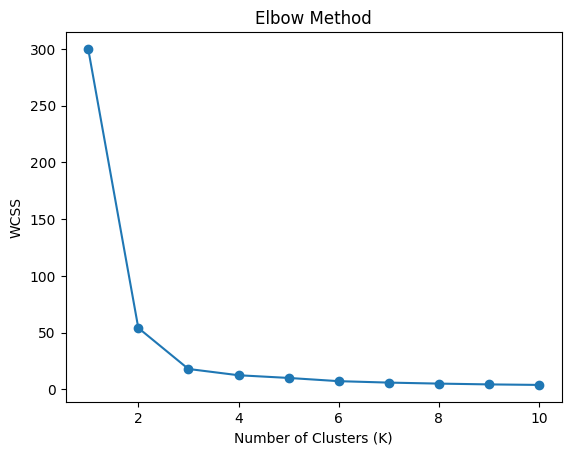

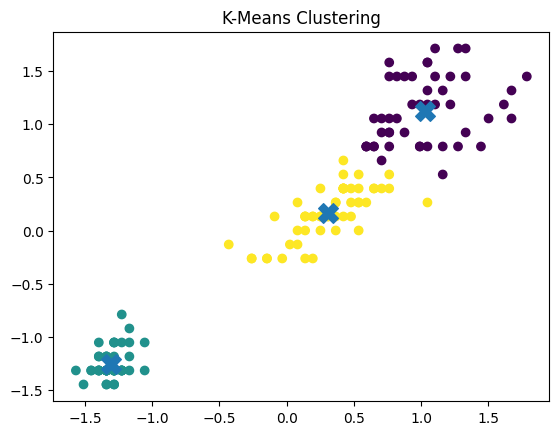

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris # Import load_iris

# Load dataset from sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Use only petal length and width
X = df[['petal length (cm)', 'petal width (cm)']]

# Optional scaling (recommended)
scholer = StandardScaler()
X_scaled = scholer.fit_transform(X)

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto') # Added n_init='auto' to suppress future warning
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Optimal K (usually 3 for iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto') # Added n_init='auto'
y_kmeans = kmeans.fit_predict(X_scaled)

# Plot clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means Clustering")
plt.show()